<a href="https://colab.research.google.com/github/dkhan1209/3iBakery/blob/main/3iBakery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torch torchvision segment-anything opencv-python-headless pillow matplotlib


In [ ]:
import os
if not os.path.exists("sam_vit_b_01ec64.pth"):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
print("SAM checkpoint san sang.")


SAM checkpoint san sang.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = "/content/drive/MyDrive/banh"

import os
classes = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("So lop banh tim thay:", len(classes))
print(classes)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
So lop banh tim thay: 8
['Bánh_chà_bông_cây', 'Bánh_chuối_nướng', 'Bánh_da_lợn', 'Bánh_mì_bơ', 'Bánh_mì_dừa_lưới', 'Croissant', 'Egg_Tart', 'Patechaud']


In [ ]:
import random
from glob import glob

random.seed(42)
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def list_images(folder):
    files = []
    for ext in IMG_EXTS:
        files += glob(os.path.join(folder, f"*{ext}"))
        files += glob(os.path.join(folder, f"*{ext.upper()}"))
    return files

train_samples, val_samples = [], []
VAL_RATIO = 0.15

for cls in classes:
    files = list_images(os.path.join(DATASET_DIR, cls))
    random.shuffle(files)
    n_val = max(1, int(len(files) * VAL_RATIO)) if len(files) > 5 else 0
    val_samples += [(f, cls) for f in files[:n_val]]
    train_samples += [(f, cls) for f in files[n_val:]]

print(f"Train: {len(train_samples)} anh | Val: {len(val_samples)} anh")


Train: 1696 anh | Val: 297 anh


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class BanhDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        label = class_to_idx[cls]
        return img, label

train_ds = BanhDataset(train_samples, train_tf)
val_ds = BanhDataset(val_samples, val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))


Train batches: 53 | Val batches: 10


In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def build_model(num_classes, freeze_backbone=True):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

model = build_model(num_classes=len(classes))
print(model.classifier)


Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 150MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


In [ ]:
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

NUM_EPOCHS = 5

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

best_acc = 0.0
for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.3f} | "
          f"{time.time()-t0:.1f}s")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"model_state": model.state_dict(),
                    "classes": classes}, "best_banh_classifier.pth")

print("Best val acc:", best_acc)


Epoch 1/5 | Train loss 0.6632 acc 0.856 | Val loss 0.1406 acc 0.997 | 791.6s
Epoch 2/5 | Train loss 0.1214 acc 0.992 | Val loss 0.0562 acc 1.000 | 97.6s
Epoch 3/5 | Train loss 0.0643 acc 0.997 | Val loss 0.0324 acc 1.000 | 91.5s
Epoch 4/5 | Train loss 0.0481 acc 0.996 | Val loss 0.0269 acc 1.000 | 92.6s
Epoch 5/5 | Train loss 0.0364 acc 0.998 | Val loss 0.0241 acc 1.000 | 93.2s
Best val acc: 1.0


In [ ]:
# Mo bang cac layer cuoi cua MobileNetV2 de fine-tune sau hon
for param in model.features[-4:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

FINE_TUNE_EPOCHS = 8
for epoch in range(FINE_TUNE_EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()
    print(f"[Fine-tune] Epoch {epoch+1}/{FINE_TUNE_EPOCHS} | "
          f"Train acc {train_acc:.3f} | Val acc {val_acc:.3f}")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"model_state": model.state_dict(),
                    "classes": classes}, "best_banh_classifier.pth")

print("Best val acc sau fine-tune:", best_acc)


[Fine-tune] Epoch 1/8 | Train acc 0.998 | Val acc 1.000


KeyboardInterrupt: 

In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import numpy as np
import cv2

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=24,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    min_mask_region_area=2000,
)

def segment_banh(image_bgr, min_area_ratio=0.01, max_area_ratio=0.6, pad=8):
    """
    image_bgr: anh khay banh (OpenCV BGR)
    Tra ve: list cac anh da crop (RGB, numpy) tuong ung tung chiec banh phat hien duoc
    """
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]
    img_area = h * w

    masks = mask_generator.generate(image_rgb)

    crops = []
    boxes = []
    for m in masks:
        area = m["area"]
        if area < img_area * min_area_ratio or area > img_area * max_area_ratio:
            continue
        x, y, bw, bh = m["bbox"]
        x0 = max(0, int(x) - pad)
        y0 = max(0, int(y) - pad)
        x1 = min(w, int(x + bw) + pad)
        y1 = min(h, int(y + bh) + pad)
        crop = image_rgb[y0:y1, x0:x1]
        if crop.size == 0:
            continue
        crops.append(crop)
        boxes.append((x0, y0, x1, y1))

    return crops, boxes


In [ ]:
import torch.nn.functional as F

ckpt = torch.load("best_banh_classifier.pth", map_location=device)
classes = ckpt["classes"]
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

inference_model = build_model(num_classes=len(classes), freeze_backbone=False)
inference_model.load_state_dict(ckpt["model_state"])
inference_model.eval()

def predict_crop(crop_rgb_np, threshold=0.5):
    """crop_rgb_np: numpy array RGB (tu segment_banh)"""
    img = Image.fromarray(crop_rgb_np)
    tensor = val_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = inference_model(tensor)
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)
    label = idx_to_class[pred_idx.item()]
    confidence = conf.item()
    if confidence < threshold:
        return "Khong xac dinh", confidence
    return label, confidence


In [ ]:
import json

menu = {
    "Egg_Tart": 21000,
    "Croissant": 30000,
    "Bánh_chà_bông_cây": 27000,
    "Patechaud": 30000,
    "Bánh_mì_dừa_lưới": 15000,
    "Bánh_da_lợn": 23000,
    "Bánh_mì_bơ": 18000,
    "Bánh_chuối_nướng": 19000,

}

with open("menu.json", "w", encoding="utf-8") as f:
    json.dump(menu, f, ensure_ascii=False, indent=2)

print("Da luu menu.json")
print(menu)


Da luu menu.json
{'Egg_Tart': 21000, 'Croissant': 30000, 'Bánh_chà_bông_cây': 27000, 'Patechaud': 30000, 'Bánh_mì_dừa_lưới': 15000, 'Bánh_da_lợn': 23000, 'Bánh_mì_bơ': 18000, 'Bánh_chuối_nướng': 19000}


In [ ]:
def generate_invoice(image_bgr, conf_threshold=0.5, exclude_unknown=True):
    crops, boxes = segment_banh(image_bgr)

    with open("menu.json", "r", encoding="utf-8") as f:
        menu = json.load(f)

    items = []
    total = 0
    annotated = image_bgr.copy()

    for crop, box in zip(crops, boxes):
        label, conf = predict_crop(crop, threshold=conf_threshold)
        is_unknown = (label == "Khong xac dinh")
        x0, y0, x1, y1 = box

        if is_unknown:
            if not exclude_unknown:
                items.append({"ten_banh": label, "do_tin_cay": round(conf, 2), "gia": 0})
            cv2.rectangle(annotated, (x0, y0), (x1, y1), (0, 0, 255), 2)
            cv2.putText(annotated, "Bo qua", (x0, max(y0 - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            continue

        price = menu.get(label, 0)
        items.append({"ten_banh": label, "do_tin_cay": round(conf, 2), "gia": price})
        total += price

        cv2.rectangle(annotated, (x0, y0), (x1, y1), (0, 200, 0), 2)
        text = f"{label} - {price}d"
        cv2.putText(annotated, text, (x0, max(y0 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

    return items, total, annotated

def print_invoice(items, total):
    print("=" * 40)
    print("HOA DON THANH TOAN")
    print("=" * 40)
    if not items:
        print("Khong phat hien chiec banh nao hop le.")
    for it in items:
        print(f"{it['ten_banh']:<20} {it['gia']:>10,} d  (tin cay {it['do_tin_cay']})")
    print("-" * 40)
    print(f"{'TONG CONG':<20} {total:>10,} d")
    print("=" * 40)


Saving 1782010759462_3037025781861356076_3037025781861356076_d4e5d63382a89999adbc5ab35e2e2793.jpg to 1782010759462_3037025781861356076_3037025781861356076_d4e5d63382a89999adbc5ab35e2e2793.jpg
HOA DON THANH TOAN
Bánh_mì_bơ                 0 d  (tin cay 0.63)
----------------------------------------
TONG CONG                     0 d


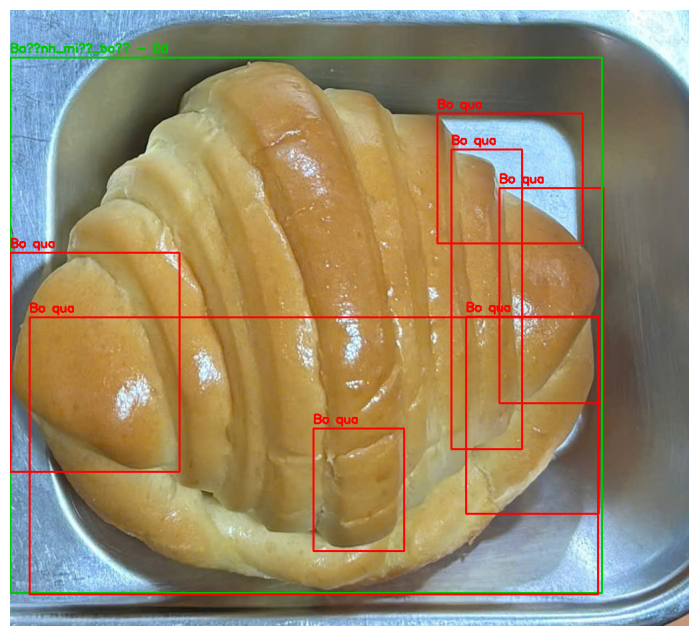

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
test_path = list(uploaded.keys())[0]

image_bgr = cv2.imread(test_path)
items, total, annotated = generate_invoice(image_bgr)
print_invoice(items, total)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo_js(filename='webcam_capture.jpg', quality=0.9):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Chup anh khay banh';
            capture.style.fontSize = '18px';
            capture.style.padding = '10px';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


photo_path = take_photo_js()
print("Da luu anh:", photo_path)

image_bgr = cv2.imread(photo_path)
items, total, annotated = generate_invoice(image_bgr)
print_invoice(items, total)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [ ]:
N_SCANS = 3

for i in range(N_SCANS):
    print(f"\n--- Luot quet {i+1}/{N_SCANS} ---")
    photo_path = take_photo_js(filename=f'webcam_capture_{i}.jpg')
    image_bgr = cv2.imread(photo_path)
    items, total, annotated = generate_invoice(image_bgr)
    print_invoice(items, total)
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


In [ ]:
!pip install -q flask flask-cors pyngrok

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import numpy as np
import threading

app = Flask(__name__)
CORS(app, resources={r"/api/*": {"origins": "*"}})

@app.route("/api/scan", methods=["POST"])
def api_scan():
    if "image" not in request.files:
        return jsonify({"error": "Khong nhan duoc anh"}), 400

    file = request.files["image"]
    file_bytes = np.frombuffer(file.read(), np.uint8)
    image_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if image_bgr is None:
        return jsonify({"error": "Anh khong hop le"}), 400

    items, total, _ = generate_invoice(image_bgr, conf_threshold=0.5, exclude_unknown=True)
    return jsonify({"items": items, "total": total})

@app.route("/", methods=["GET"])
def api_root():
    return jsonify({"status": "ok", "message": "3iBakery API dang chay. Dung /api/health hoac /api/scan"})

@app.route("/api/health", methods=["GET"])
def api_health():
    return jsonify({"status": "ok", "so_lop_banh": len(classes)})


NGROK_AUTHTOKEN = "3FPDMbnxQJ15vOIMfFmX42Sm98D_6gL8TR4yzdUreZDCQtcT9"
ngrok.set_auth_token(NGROK_AUTHTOKEN)

public_url = ngrok.connect(5000)
print("API URL (dan vao web 3iBakery):", public_url)

threading.Thread(target=lambda: app.run(port=5000)).start()


API URL (dan vao web 3iBakery): NgrokTunnel: "https://geek-pavilion-stomp.ngrok-free.dev" -> "http://localhost:5000"
